# SDC — Sistem Rekomendasi Tindakan Manajer
## Berbasis Model Klasifikasi Machine Learning

**Proyek:** SDC Dashboard – Monitoring & Evaluasi Sertifikasi Tenaga Kerja Pariwisata  
**Scope notebook ini:**
1. Eksplorasi & validasi data (EDA)
2. Preprocessing & feature engineering
3. Training multi-model klasifikasi
4. Evaluasi & perbandingan model
5. Analisis feature importance
6. Hyperparameter tuning — model terbaik
7. Inference — simulasi rekomendasi tindakan untuk manajer

---
**Alur sistem:**
```
Profil pegawai (skill + kinerja + skor)  →  Model Klasifikasi  →  Label Tindakan  →  Panduan tindakan spesifik
```

**5 Label Tindakan Manajer:**
- `0` — Coaching Intensif
- `1` — Pengawasan & Evaluasi Ketat
- `2` — Pertahankan & Stabilkan
- `3` — Percepatan Karir
- `4` — Retensi & Risiko Resign


## 0. Setup & Import Library

In [2]:
# Install dependencies jika belum ada
# !pip install scikit-learn imbalanced-learn pandas numpy matplotlib seaborn -q


In [3]:
import warnings
warnings.filterwarnings("ignore")

# Core
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing & pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Model klasifikasi
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluasi
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    roc_auc_score, roc_curve, auc
)

# Imbalanced — pipeline terintegrasi agar SMOTE tidak bocor ke CV fold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Reproducibility
SEED = 42
np.random.seed(SEED)

LABEL_TINDAKAN = {
    0: "Coaching Intensif",
    1: "Pengawasan & Evaluasi Ketat",
    2: "Pertahankan & Stabilkan",
    3: "Percepatan Karir",
    4: "Retensi & Risiko Resign",
}
LABEL_TINDAKAN_LIST = [LABEL_TINDAKAN[i] for i in range(5)]

print("Library berhasil diimport.")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")


Library berhasil diimport.
Scikit-learn version: 1.9.0


---
## 1. Load & Eksplorasi Data (EDA)

Dataset yang digunakan:
- `data_pegawai_v2.csv` — 400 baris, fitur skill pegawai + dua label ground truth
  - `label_rekomendasi` — rekomendasi course (4 kelas)
  - `label_tindakan` — rekomendasi tindakan manajer (5 kelas) ← **target notebook ini**


In [ ]:
# ── Load data
df_pegawai = pd.read_csv("data_pegawai.csv")

print(f"Data Pegawai : {df_pegawai.shape[0]} baris × {df_pegawai.shape[1]} kolom")


FileNotFoundError: [Errno 2] No such file or directory: '/content/data_pegawai_v2.csv'

In [ ]:
# ── Gambaran umum data pegawai
print("=== 5 baris pertama ===")
df_pegawai.head()


=== 5 baris pertama ===


,id_pegawai,nama_pegawai,jabatan,divisi,status_sertifikat,pre_score,post_score,kinerja_q1_2024,kinerja_q2_2024,kinerja_q3_2024,...,skill_penguasaan_teknis,skill_kepatuhan_sop,skill_kepemimpinan,skill_bahasa_asing,skill_problem_solving,skill_digital_literacy,label_rekomendasi,label_rekomendasi_nama,label_tindakan,label_tindakan_nama
0,EMP0001,Budi Wijaya Kurniawan,Front Desk Officer,Akomodasi,Aktif,45,76,2.89,3.00,2.95,...,3.61,4.12,1.73,3.00,3.27,3.00,3,Sertifikasi Lanjutan & Pengembangan Karir,1,Pengawasan & Evaluasi Ketat
1,EMP0002,Nabila Nugraha Maulana,Front Desk Officer,Akomodasi,Aktif,46,67,2.96,2.96,2.97,...,3.00,4.00,2.43,4.07,3.12,3.00,1,Teknis & Kepatuhan SOP,2,Pertahankan & Stabilkan
2,EMP0003,Budi Kusuma Prasetyo,Front Desk Officer,Akomodasi,Aktif,50,79,2.97,2.99,3.09,...,3.82,3.54,2.34,3.00,4.00,3.91,3,Sertifikasi Lanjutan & Pengembangan Karir,2,Pertahankan & Stabilkan
3,EMP0004,Farah Wibowo Maulana,Front Desk Officer,Akomodasi,Aktif,43,74,2.63,2.83,2.90,...,2.40,3.42,3.00,3.05,3.05,5.00,1,Teknis & Kepatuhan SOP,3,Percepatan Karir
4,EMP0005,Fajar Nugraha Anggraini,Front Desk Officer,Akomodasi,Belum,45,65,3.00,2.84,2.70,...,4.00,3.49,2.10,3.00,3.00,3.77,3,Sertifikasi Lanjutan & Pengembangan Karir,1,Pengawasan & Evaluasi Ketat


In [ ]:
# ── Tipe data & missing values
print("Info kolom:")
df_pegawai.info()
print(f"\nTotal missing values: {df_pegawai.isnull().sum().sum()}")


Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_pegawai               400 non-null    object 
 1   nama_pegawai             400 non-null    object 
 2   jabatan                  400 non-null    object 
 3   divisi                   400 non-null    object 
 4   status_sertifikat        400 non-null    object 
 5   pre_score                400 non-null    int64  
 6   post_score               400 non-null    int64  
 7   kinerja_q1_2024          400 non-null    float64
 8   kinerja_q2_2024          400 non-null    float64
 9   kinerja_q3_2024          400 non-null    float64
 10  kinerja_q4_2024          400 non-null    float64
 11  kinerja_q1_2025          400 non-null    float64
 12  kinerja_q2_2025          400 non-null    float64
 13  skill_komunikasi         400 non-null    float64
 14  skill_layanan_

In [ ]:
# ── Statistik deskriptif skill
skill_cols = [c for c in df_pegawai.columns if c.startswith("skill_")]
print("Statistik 8 dimensi skill (skala 1.0 – 5.0):")
df_pegawai[skill_cols].describe().round(3)


Statistik 8 dimensi skill (skala 1.0 – 5.0):


,skill_komunikasi,skill_layanan_tamu,skill_penguasaan_teknis,skill_kepatuhan_sop,skill_kepemimpinan,skill_bahasa_asing,skill_problem_solving,skill_digital_literacy
count,400.000,400.000,400.000,400.000,400.000,400.000,400.000,400.000
mean,3.449,3.688,3.588,3.803,2.841,3.013,3.202,3.052
std,0.712,0.667,0.728,0.625,0.901,0.856,0.751,0.836
min,1.160,1.780,1.880,2.000,1.000,1.000,1.290,1.000
25%,3.000,3.070,3.000,3.340,2.027,2.420,2.798,2.428
50%,3.410,3.810,3.665,3.940,2.950,3.000,3.035,3.000
75%,4.000,4.000,4.000,4.110,3.378,3.592,3.872,3.802
max,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000


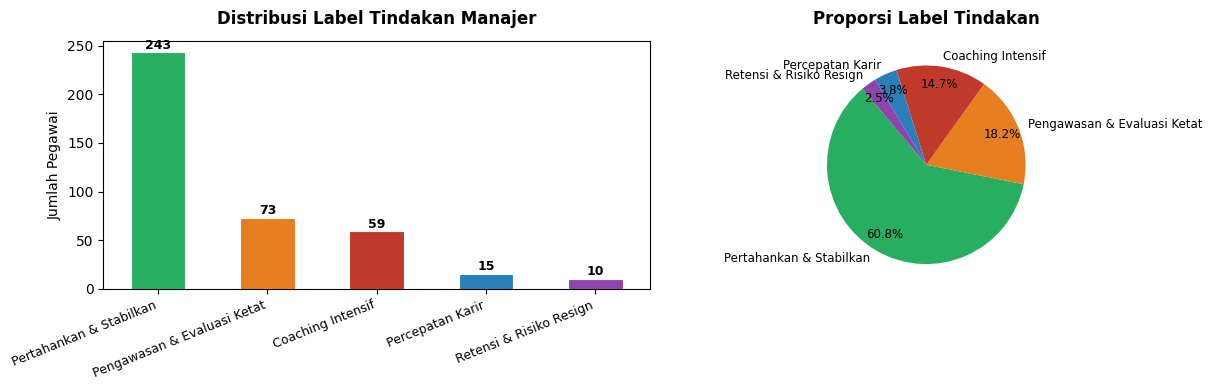


Class balance:
  Pertahankan & Stabilkan             : 243 (60.8%)
  Pengawasan & Evaluasi Ketat         : 73 (18.2%)
  Coaching Intensif                   : 59 (14.8%)
  Percepatan Karir                    : 15 (3.8%)
  Retensi & Risiko Resign             : 10 (2.5%)


In [ ]:
# ── Distribusi label tindakan
label_counts = df_pegawai["label_tindakan_nama"].value_counts()

COLORS = {
    "Coaching Intensif":           "#c0392b",
    "Pengawasan & Evaluasi Ketat": "#e67e22",
    "Pertahankan & Stabilkan":     "#27ae60",
    "Percepatan Karir":            "#2980b9",
    "Retensi & Risiko Resign":     "#8e44ad",
}
bar_colors = [COLORS[l] for l in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_counts.plot(kind="bar", ax=axes[0], color=bar_colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Distribusi Label Tindakan Manajer", fontweight="bold", pad=12)
axes[0].set_xlabel("")
axes[0].set_xticklabels(label_counts.index, rotation=22, ha="right", fontsize=9)
axes[0].set_ylabel("Jumlah Pegawai")
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

axes[1].pie(label_counts.values, labels=label_counts.index,
            colors=bar_colors, autopct="%1.1f%%", startangle=130,
            textprops={"fontsize": 8.5}, pctdistance=0.82)
axes[1].set_title("Proporsi Label Tindakan", fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("tindakan_plot_label_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nClass balance:")
for name, cnt in label_counts.items():
    print(f"  {name:<35} : {cnt} ({cnt/len(df_pegawai)*100:.1f}%)")


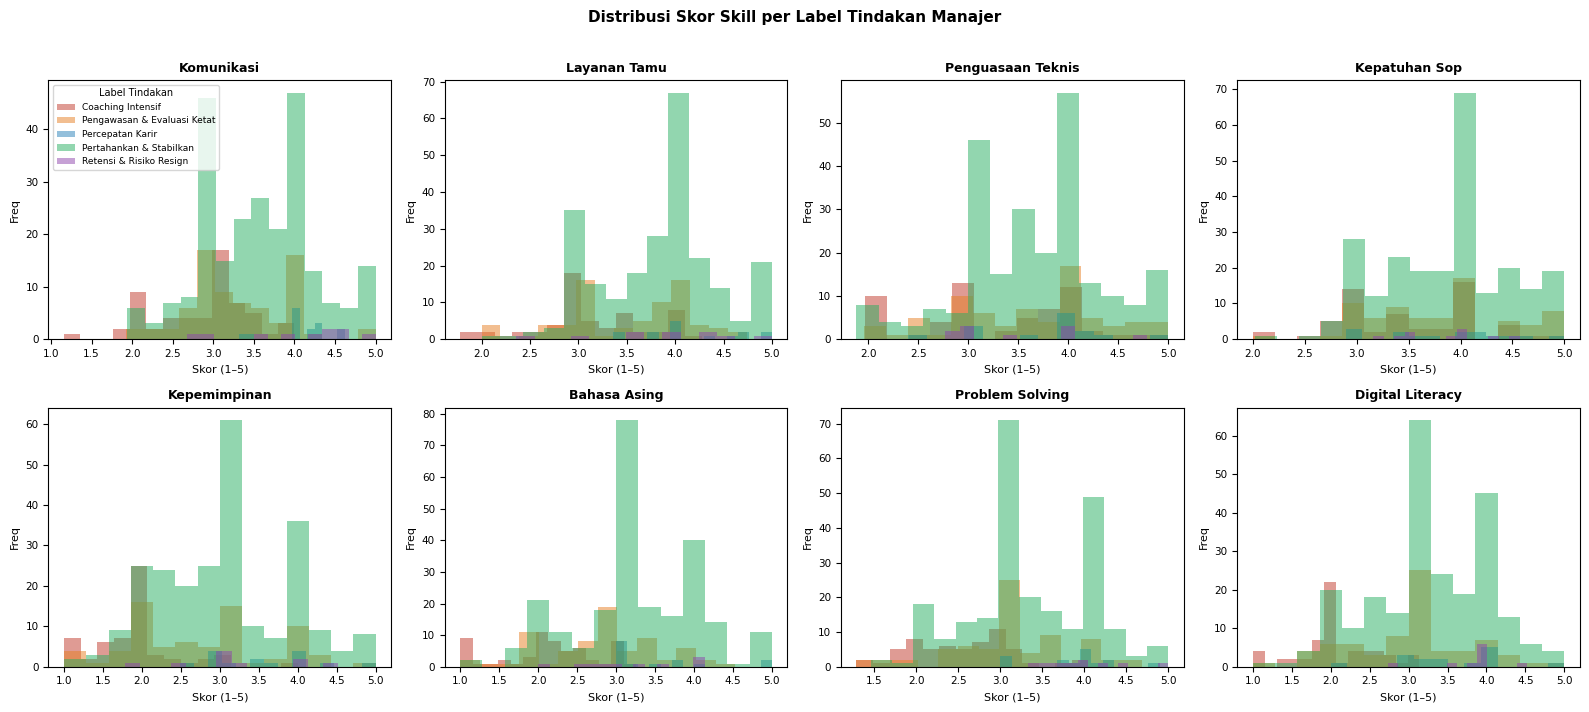

In [ ]:
# ── Distribusi skill per label tindakan
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, skill in enumerate(skill_cols):
    label_name = skill.replace("skill_", "").replace("_", " ").title()
    for label, grp in df_pegawai.groupby("label_tindakan_nama"):
        axes[i].hist(grp[skill], bins=14, alpha=0.50,
                     color=COLORS[label], label=label, edgecolor="none")
    axes[i].set_title(label_name, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Skor (1–5)", fontsize=8)
    axes[i].set_ylabel("Freq", fontsize=8)
    axes[i].tick_params(labelsize=7.5)

axes[0].legend(fontsize=6.5, loc="upper left", title="Label Tindakan", title_fontsize=7)
plt.suptitle("Distribusi Skor Skill per Label Tindakan Manajer",
             fontweight="bold", y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig("tindakan_plot_skill_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


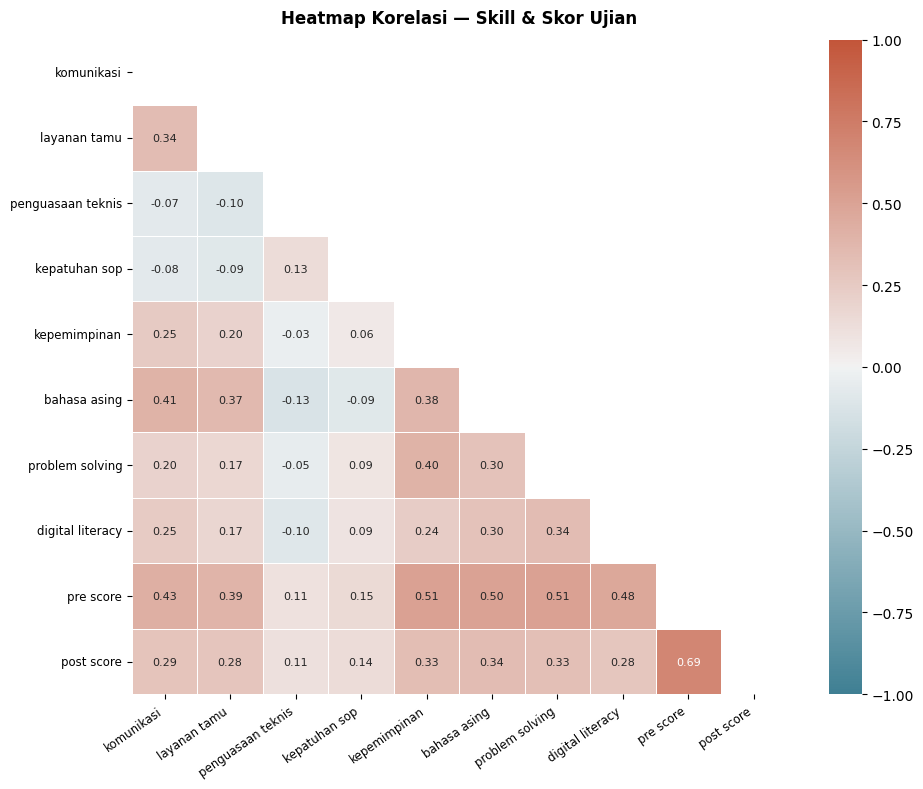

In [ ]:
# ── Heatmap korelasi antar skill
kinerja_cols = [c for c in df_pegawai.columns if c.startswith("kinerja_")]
corr = df_pegawai[skill_cols + ["pre_score", "post_score"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, annot_kws={"size": 8}, ax=ax)
ax.set_xticklabels(
    [c.replace("skill_","").replace("_"," ") for c in corr.columns],
    rotation=35, ha="right", fontsize=8.5)
ax.set_yticklabels(
    [c.replace("skill_","").replace("_"," ") for c in corr.index],
    rotation=0, fontsize=8.5)
ax.set_title("Heatmap Korelasi — Skill & Skor Ujian", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("tindakan_plot_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


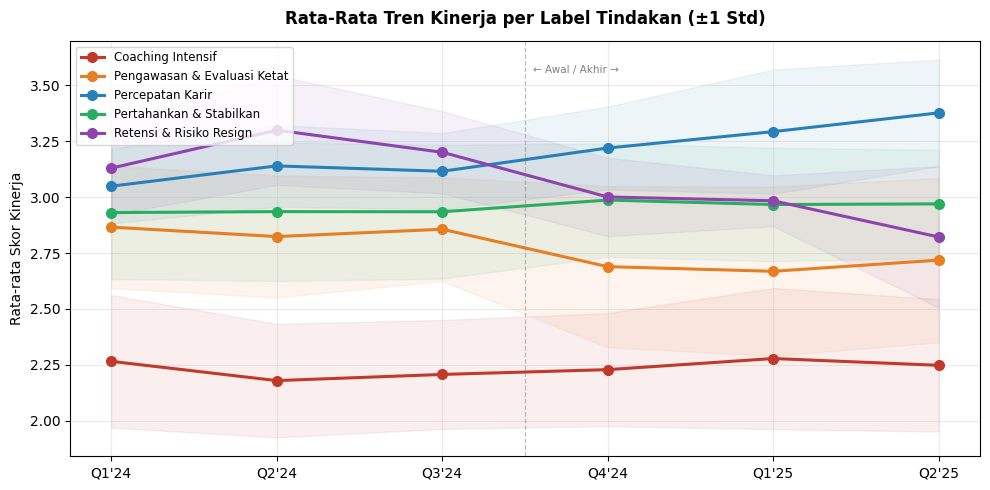

In [ ]:
# ── Tren kinerja rata-rata per label tindakan
quarter_labels = ["Q1'24", "Q2'24", "Q3'24", "Q4'24", "Q1'25", "Q2'25"]

fig, ax = plt.subplots(figsize=(10, 5))
for label_name, grp in df_pegawai.groupby("label_tindakan_nama"):
    mean_k = grp[kinerja_cols].mean().values
    std_k  = grp[kinerja_cols].std().values
    ax.plot(quarter_labels, mean_k, marker="o", linewidth=2.2,
            markersize=7, color=COLORS[label_name], label=label_name)
    ax.fill_between(quarter_labels, mean_k - std_k, mean_k + std_k,
                    alpha=0.08, color=COLORS[label_name])

ax.axvline(2.5, color="gray", linestyle="--", linewidth=0.9, alpha=0.5)
ax.text(2.55, ax.get_ylim()[1] * 0.97, "← Awal / Akhir →",
        fontsize=7.5, color="gray", va="top")
ax.set_title("Rata-Rata Tren Kinerja per Label Tindakan (±1 Std)",
             fontweight="bold", pad=12)
ax.set_ylabel("Rata-rata Skor Kinerja")
ax.legend(fontsize=8.5, loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("tindakan_plot_kinerja_trend.png", dpi=120, bbox_inches="tight")
plt.show()


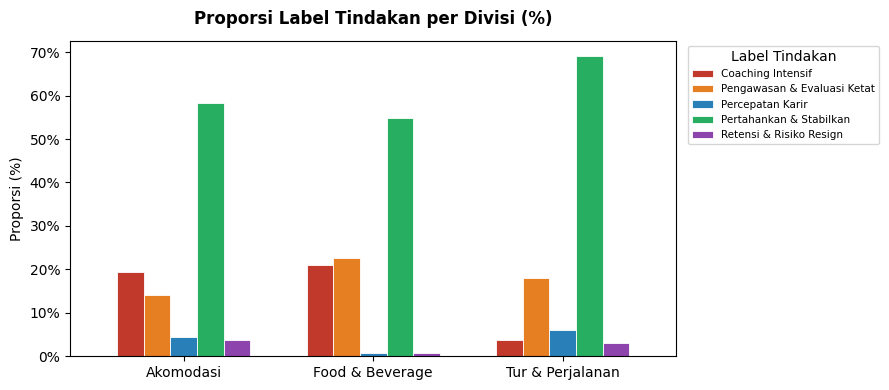

In [ ]:
# ── Distribusi label per divisi
cross = pd.crosstab(df_pegawai["divisi"], df_pegawai["label_tindakan_nama"],
                    normalize="index") * 100

colors_bar = [COLORS[c] for c in cross.columns]
fig, ax = plt.subplots(figsize=(9, 4))
cross.plot(kind="bar", ax=ax, color=colors_bar, edgecolor="white",
           linewidth=0.6, width=0.7)
ax.set_title("Proporsi Label Tindakan per Divisi (%)", fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Proporsi (%)")
ax.set_xticklabels(cross.index, rotation=0, fontsize=10)
ax.legend(fontsize=7.5, bbox_to_anchor=(1.01, 1), loc="upper left",
          title="Label Tindakan")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig("tindakan_plot_label_per_divisi.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 2. Preprocessing & Feature Engineering

**Fitur yang digunakan:**
- 8 dimensi skill (numerik, skala 1–5) — fitur utama
- `pre_score`, `post_score` — skor ujian (numerik)
- `kinerja_q*` — skor kinerja 6 kuartal (numerik)
- `divisi`, `status_sertifikat` — fitur kategorikal

**Feature engineering tambahan:**
- `delta_score` = post_score − pre_score
- `avg_skill` = rata-rata 8 dimensi skill
- `avg_kinerja_awal` = rata-rata kinerja Q1–Q3 2024
- `avg_kinerja_akhir` = rata-rata kinerja Q4 2024–Q2 2025
- `delta_kinerja` = avg_kinerja_akhir − avg_kinerja_awal *(negatif = tren turun)*
- `is_sudden_drop` = flag biner: kinerja awal ≥ 3.0 tapi turun ≥ 0.20


In [ ]:
# ── Feature engineering
df = df_pegawai.copy()

df["delta_score"]        = df["post_score"] - df["pre_score"]
df["avg_skill"]          = df[skill_cols].mean(axis=1).round(3)
df["avg_kinerja_awal"]   = df[["kinerja_q1_2024","kinerja_q2_2024",
                                "kinerja_q3_2024"]].mean(axis=1).round(3)
df["avg_kinerja_akhir"]  = df[["kinerja_q4_2024","kinerja_q1_2025",
                                "kinerja_q2_2025"]].mean(axis=1).round(3)
df["delta_kinerja"]      = (df["avg_kinerja_akhir"] - df["avg_kinerja_awal"]).round(3)
df["is_sudden_drop"]     = (
    (df["avg_kinerja_awal"] >= 3.0) & (df["delta_kinerja"] <= -0.20)
).astype(int)

new_feats = ["delta_score","avg_skill","avg_kinerja_awal",
             "avg_kinerja_akhir","delta_kinerja","is_sudden_drop"]
print("Feature engineering selesai. Stats fitur baru:")
print(df[new_feats].describe().round(3).to_string())


Feature engineering selesai. Stats fitur baru:
       delta_score  avg_skill  avg_kinerja_awal  avg_kinerja_akhir  delta_kinerja  is_sudden_drop
count      400.000    400.000           400.000            400.000        400.000         400.000
mean        22.055      3.329             2.826              2.828          0.002           0.032
std          7.024      0.388             0.346              0.343          0.180           0.178
min          9.000      2.189             1.940              1.857         -0.510           0.000
25%         16.000      3.057             2.650              2.627         -0.110           0.000
50%         22.000      3.380             2.938              2.923         -0.003           0.000
75%         28.000      3.612             3.053              3.047          0.097           0.000
max         35.000      4.269             3.490              3.523          0.580           1.000


In [ ]:
# ── Definisi fitur & target
NUMERIC_FEATURES = (
    skill_cols
    + ["pre_score", "post_score", "delta_score"]
    + ["avg_skill"]
    + ["avg_kinerja_awal", "avg_kinerja_akhir", "delta_kinerja"]
    + ["is_sudden_drop"]
    + kinerja_cols
)
CATEGORICAL_FEATURES = ["divisi", "status_sertifikat"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "label_tindakan"

print(f"Total fitur     : {len(ALL_FEATURES)}")
print(f"  - Numerik     : {len(NUMERIC_FEATURES)}")
print(f"  - Kategorikal : {len(CATEGORICAL_FEATURES)}")
print(f"Target          : {TARGET} (5 kelas)")


Total fitur     : 24
  - Numerik     : 22
  - Kategorikal : 2
Target          : label_tindakan (5 kelas)


In [ ]:
# ── Train-test split (stratified 80/20)
X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train set : {X_train.shape[0]} sampel")
print(f"Test set  : {X_test.shape[0]} sampel")
print(f"\nDistribusi label di train set:")
print(y_train.value_counts().sort_index())
print(f"\nDistribusi label di test set:")
print(y_test.value_counts().sort_index())


Train set : 320 sampel
Test set  : 80 sampel

Distribusi label di train set:
label_tindakan
0     47
1     58
2    195
3     12
4      8
Name: count, dtype: int64

Distribusi label di test set:
label_tindakan
0    12
1    15
2    48
3     3
4     2
Name: count, dtype: int64


In [ ]:
# ── Preprocessing pipeline
numeric_transformer     = Pipeline([("scaler", StandardScaler())])
categorical_transformer = Pipeline([
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,     NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Shape setelah preprocessing:")
print(f"  X_train : {X_train_proc.shape}")
print(f"  X_test  : {X_test_proc.shape}")


Shape setelah preprocessing:
  X_train : (320, 28)
  X_test  : (80, 28)


In [ ]:
# ── Class imbalance — SMOTE diintegrasikan dalam ImbPipeline
# Ini memastikan SMOTE hanya diterapkan pada training fold (tidak bocor ke validasi)
from collections import Counter

print("Distribusi kelas sebelum SMOTE:", Counter(y_train))
print()
print("Catatan: SMOTE akan dijalankan di dalam setiap fold CV via ImbPipeline.")
print("Tidak perlu fit SMOTE secara manual di sini.")
print()

label_names_map = (
    df_pegawai[["label_tindakan", "label_tindakan_nama"]]
    .drop_duplicates()
    .set_index("label_tindakan")["label_tindakan_nama"]
    .to_dict()
)
print("Keterangan label:")
for k, v in sorted(label_names_map.items()):
    print(f"  {k} = {v}")


Distribusi kelas sebelum SMOTE: Counter({2: 195, 1: 58, 0: 47, 3: 12, 4: 8})

Catatan: SMOTE akan dijalankan di dalam setiap fold CV via ImbPipeline.
Tidak perlu fit SMOTE secara manual di sini.

Keterangan label:
  0 = Coaching Intensif
  1 = Pengawasan & Evaluasi Ketat
  2 = Pertahankan & Stabilkan
  3 = Percepatan Karir
  4 = Retensi & Risiko Resign


---
## 3. Training Multi-Model Klasifikasi

Model yang akan dibandingkan:

| # | Model | Keterangan |
|---|-------|-----------|
| 1 | Logistic Regression | Baseline linear |
| 2 | Decision Tree | Interpretable, prone to overfit |
| 3 | Random Forest | Ensemble bagging |
| 4 | Gradient Boosting | Ensemble boosting |
| 5 | Extra Trees | Randomized ensemble |
| 6 | SVM (RBF kernel) | Margin-based, nonlinear |
| 7 | K-Nearest Neighbors | Instance-based |
| 8 | Naive Bayes | Probabilistic baseline |

Setiap model dijalankan dalam `ImbPipeline` (SMOTE → model) sehingga
SMOTE **tidak bocor** ke validation fold saat cross-validation.


In [ ]:
# ── Definisi semua model
MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=SEED, C=1.0
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=4, random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        random_state=SEED
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    ),
    "SVM (RBF)": SVC(
        kernel="rbf", C=1.0, gamma="scale",
        probability=True, random_state=SEED
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5, weights="distance", n_jobs=-1
    ),
    "Naive Bayes": GaussianNB(),
}

print(f"{len(MODELS)} model siap dilatih.")


8 model siap dilatih.


In [ ]:
# ── Training & evaluasi semua model
results = {}

print(f"{'Model':<25} {'CV F1-macro':>12} {'Test Accuracy':>14} {'Test F1-macro':>14}")
print("-" * 68)

for name, model in MODELS.items():
    # ImbPipeline: SMOTE hanya aktif di training fold, tidak bocor ke validasi
    cv_pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=SEED, k_neighbors=2)),
        ("clf",   model)
    ])

    cv_scores = cross_val_score(
        cv_pipeline, X_train_proc, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="f1_macro",
        n_jobs=-1
    )

    # Fit ulang pada full train set
    cv_pipeline.fit(X_train_proc, y_train)

    y_pred   = cv_pipeline.predict(X_test_proc)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average="macro")

    results[name] = {
        "model":    cv_pipeline,
        "cv_mean":  cv_scores.mean(),
        "cv_std":   cv_scores.std(),
        "test_acc": test_acc,
        "test_f1":  test_f1,
        "y_pred":   y_pred,
    }

    print(f"{name:<25} {cv_scores.mean():.4f} ± {cv_scores.std():.3f}   "
          f"{test_acc:.4f}         {test_f1:.4f}")

print("\nTraining selesai.")


Model                      CV F1-macro  Test Accuracy  Test F1-macro
--------------------------------------------------------------------
Logistic Regression       0.7944 ± 0.043   0.7875         0.7503
Decision Tree             0.7948 ± 0.135   0.8875         0.7527
Random Forest             0.9221 ± 0.037   0.9500         0.9298
Gradient Boosting         0.9014 ± 0.092   0.9625         0.9206
Extra Trees               0.8325 ± 0.063   0.8750         0.8739
SVM (RBF)                 0.8438 ± 0.048   0.8375         0.8601
KNN                       0.7240 ± 0.032   0.7375         0.7647
Naive Bayes               0.6303 ± 0.118   0.7125         0.6848

Training selesai.


---
## 4. Evaluasi & Perbandingan Model


In [ ]:
# ── Ringkasan performa semua model
df_results = pd.DataFrame([
    {
        "Model":               name,
        "CV F1-macro (mean)":  r["cv_mean"],
        "CV F1-macro (std)":   r["cv_std"],
        "Test Accuracy":       r["test_acc"],
        "Test F1-macro":       r["test_f1"],
        "CV-Test Gap":         round(r["cv_mean"] - r["test_f1"], 4),
        "Suspect Overfit":
          "YA" if r["test_f1"] >= 0.999 else "Gap Besar" if abs(r["cv_mean"] - r["test_f1"]) > 0.15 else "OK",
    }
    for name, r in results.items()
]).sort_values("Test F1-macro", ascending=False).reset_index(drop=True)
df_results.index += 1

# Model terbaik yang valid: F1 tidak sempurna & gap tidak terlalu besar
df_valid = df_results[
    (df_results["Test F1-macro"] < 0.999) &
    (df_results["CV-Test Gap"].abs() < 0.15)
]
best_name_safe = df_valid.iloc[0]["Model"] if len(df_valid) > 0 else df_results.iloc[0]["Model"]

print("=== Perbandingan Model (diurutkan Test F1-macro) ===")
print(df_results.to_string())

excluded     = df_results[df_results["Suspect Overfit"] == "YA"]["Model"].tolist()
excluded_str = ", ".join(excluded) if excluded else "tidak ada"
print(f"\n  Model yang dikecualikan karena suspect overfit: {excluded_str}")
print(f"\n  Model terbaik yang valid untuk produksi: {best_name_safe}")


=== Perbandingan Model (diurutkan Test F1-macro) ===
                 Model  CV F1-macro (mean)  CV F1-macro (std)  Test Accuracy  Test F1-macro  CV-Test Gap Suspect Overfit
1        Random Forest            0.922070           0.036620         0.9500       0.929778      -0.0077              OK
2    Gradient Boosting            0.901436           0.091885         0.9625       0.920566      -0.0191              OK
3          Extra Trees            0.832495           0.063425         0.8750       0.873915      -0.0414              OK
4            SVM (RBF)            0.843760           0.048154         0.8375       0.860099      -0.0163              OK
5                  KNN            0.723997           0.032336         0.7375       0.764747      -0.0407              OK
6        Decision Tree            0.794801           0.135156         0.8875       0.752676       0.0421              OK
7  Logistic Regression            0.794388           0.043264         0.7875       0.750251       0.

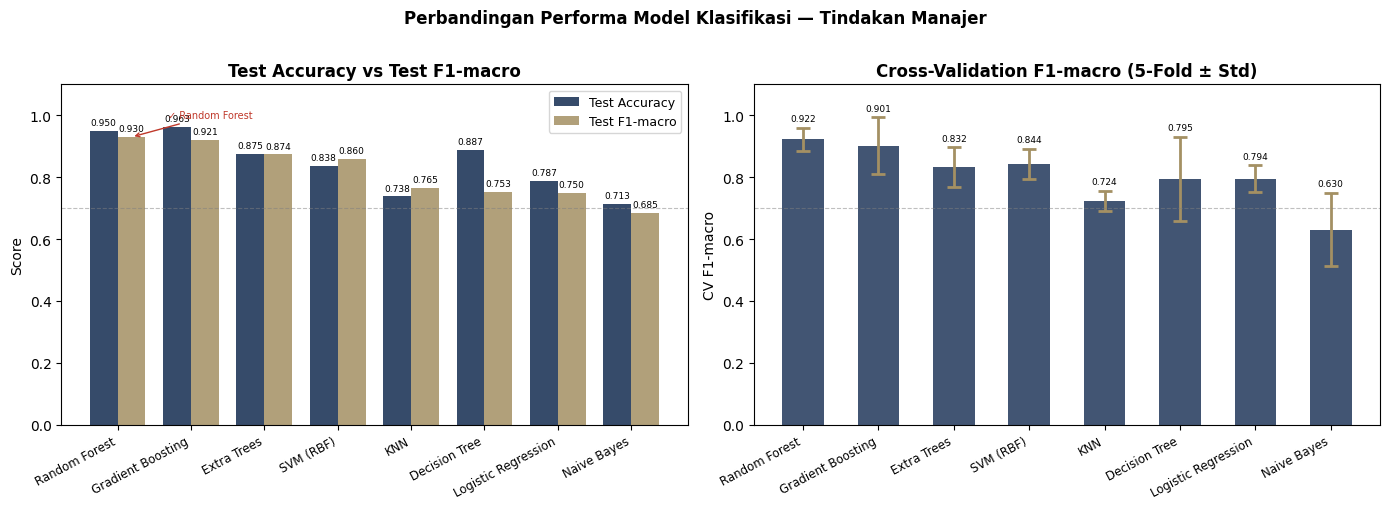

In [ ]:
# ── Visualisasi perbandingan
model_names = df_results["Model"].tolist()
test_acc    = df_results["Test Accuracy"].tolist()
test_f1     = df_results["Test F1-macro"].tolist()
cv_mean     = df_results["CV F1-macro (mean)"].tolist()
cv_std      = df_results["CV F1-macro (std)"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(model_names))
w = 0.38

bars1 = axes[0].bar(x - w/2, test_acc, w, label="Test Accuracy",  color="#132B50", alpha=0.85)
bars2 = axes[0].bar(x + w/2, test_f1,  w, label="Test F1-macro",  color="#A49063", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=28, ha="right", fontsize=8.5)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Test Accuracy vs Test F1-macro", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=6.5)

# Tandai model terpilih
best_idx = model_names.index(best_name_safe)
axes[0].annotate(f"✓ {best_name_safe}",
                 xy=(best_idx + w/2, test_f1[best_idx]),
                 xytext=(best_idx + w/2 + 0.5, test_f1[best_idx] + 0.06),
                 fontsize=7, color="#c0392b",
                 arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1))

axes[1].bar(x, cv_mean, 0.55, color="#132B50", alpha=0.8, label="CV F1-macro")
axes[1].errorbar(x, cv_mean, yerr=cv_std, fmt="none",
                 color="#A49063", capsize=5, linewidth=2, capthick=2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=28, ha="right", fontsize=8.5)
axes[1].set_ylabel("CV F1-macro")
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Cross-Validation F1-macro (5-Fold ± Std)", fontweight="bold")
axes[1].axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
for i, (m, s) in enumerate(zip(cv_mean, cv_std)):
    axes[1].text(i, m + s + 0.015, f"{m:.3f}", ha="center", va="bottom", fontsize=6.5)

plt.suptitle("Perbandingan Performa Model Klasifikasi — Tindakan Manajer",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tindakan_plot_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


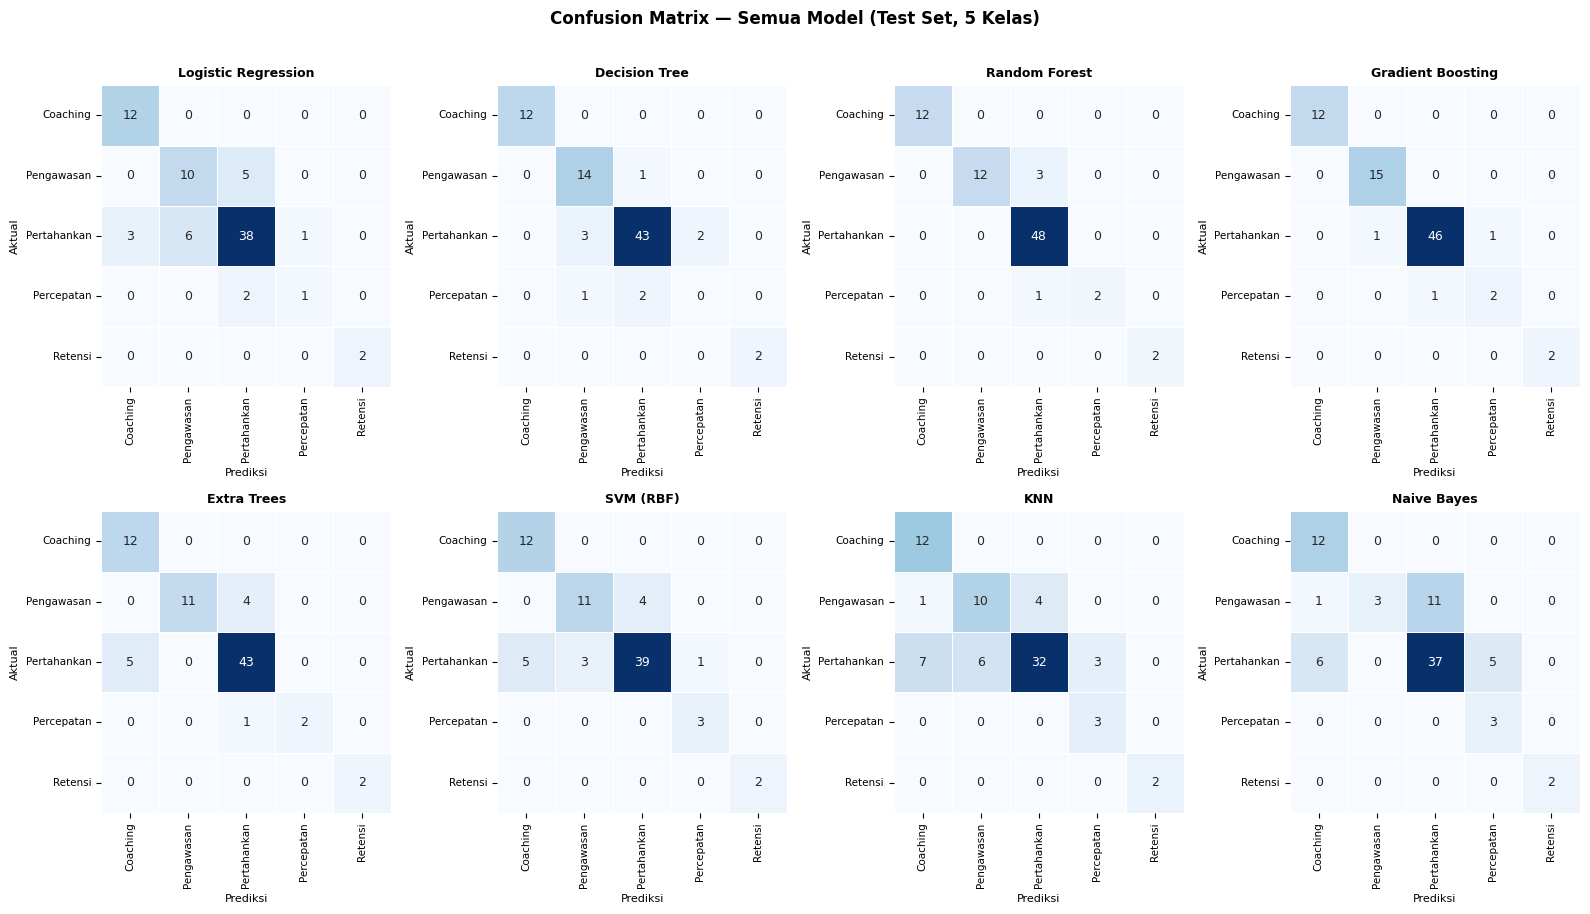

In [ ]:
# ── Confusion matrix semua model
LABEL_SHORT = ["Coaching", "Pengawasan", "Pertahankan", "Percepatan", "Retensi"]

n_models = len(MODELS)
ncols    = 4
nrows    = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4 + 1))
axes = axes.flatten()

for idx, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABEL_SHORT, yticklabels=LABEL_SHORT,
                ax=axes[idx], linewidths=0.5, cbar=False,
                annot_kws={"size": 9})
    axes[idx].set_title(name, fontsize=9, fontweight="bold", pad=6)
    axes[idx].set_xlabel("Prediksi", fontsize=8)
    axes[idx].set_ylabel("Aktual", fontsize=8)
    axes[idx].tick_params(labelsize=7.5)

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Confusion Matrix — Semua Model (Test Set, 5 Kelas)",
             fontweight="bold", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("tindakan_plot_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# ── Classification report model terbaik
best_res = results[best_name_safe]

print(f"=== Classification Report: {best_name_safe} ===")
print(f"(Dipilih karena F1 realistis dan CV-Test gap wajar)")
print(f"Test Accuracy : {best_res['test_acc']:.4f}")
print(f"Test F1-macro : {best_res['test_f1']:.4f}")
print()
print(classification_report(
    y_test, best_res["y_pred"],
    target_names=LABEL_TINDAKAN_LIST
))


=== Classification Report: Random Forest ===
(Dipilih karena F1 realistis dan CV-Test gap wajar)
Test Accuracy : 0.9500
Test F1-macro : 0.9298

                             precision    recall  f1-score   support

          Coaching Intensif       1.00      1.00      1.00        12
Pengawasan & Evaluasi Ketat       1.00      0.80      0.89        15
    Pertahankan & Stabilkan       0.92      1.00      0.96        48
           Percepatan Karir       1.00      0.67      0.80         3
    Retensi & Risiko Resign       1.00      1.00      1.00         2

                   accuracy                           0.95        80
                  macro avg       0.98      0.89      0.93        80
               weighted avg       0.95      0.95      0.95        80



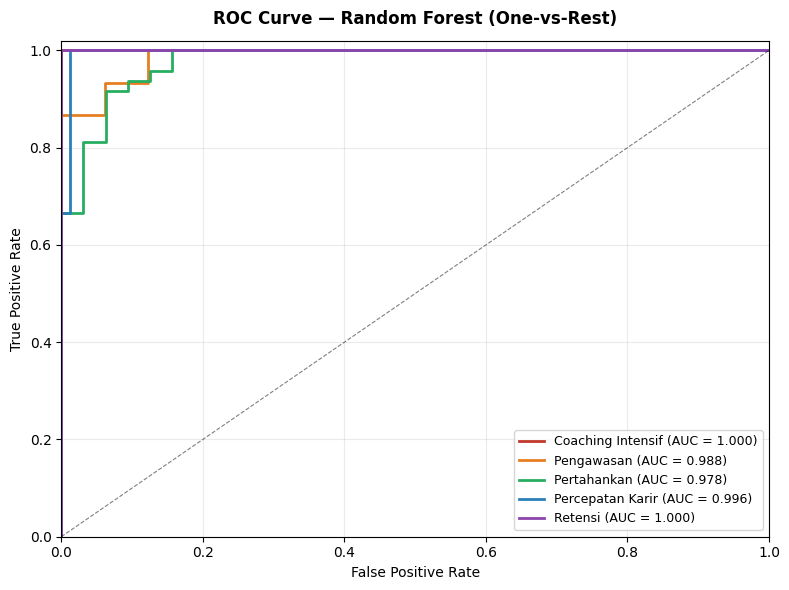


Macro-average AUC (Random Forest): 0.9922


In [ ]:
# ── ROC-AUC Curve (One-vs-Rest) — model terbaik
best_model = best_res["model"]
n_classes  = 5
colors_roc = ["#c0392b", "#e67e22", "#27ae60", "#2980b9", "#8e44ad"]

y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
y_score    = best_model.predict_proba(X_test_proc)

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_val = auc(fpr, tpr)
    short = LABEL_TINDAKAN_LIST[i].split("&")[0].strip()
    ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
            label=f"{short} (AUC = {roc_auc_val:.3f})")

ax.plot([0,1],[0,1], "k--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate", fontsize=10)
ax.set_title(f"ROC Curve — {best_name_safe} (One-vs-Rest)",
             fontweight="bold", pad=12)
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("tindakan_plot_roc_curve.png", dpi=120, bbox_inches="tight")
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
print(f"\nMacro-average AUC ({best_name_safe}): {macro_auc:.4f}")


---
## 5. Analisis Feature Importance

Metode importance dipilih otomatis berdasarkan model terpilih:
- **Built-in importance** — untuk model tree-based (RF, GB, ET, DT)
- **Permutation importance** — untuk model lain (SVM, LR, KNN, NB)


In [ ]:
# ── Nama fitur setelah preprocessing
ohe_feature_names = preprocessor.named_transformers_["cat"]["ohe"] \
                    .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERIC_FEATURES + ohe_feature_names

print(f"Total fitur setelah encoding: {len(all_feature_names)}")


Total fitur setelah encoding: 28


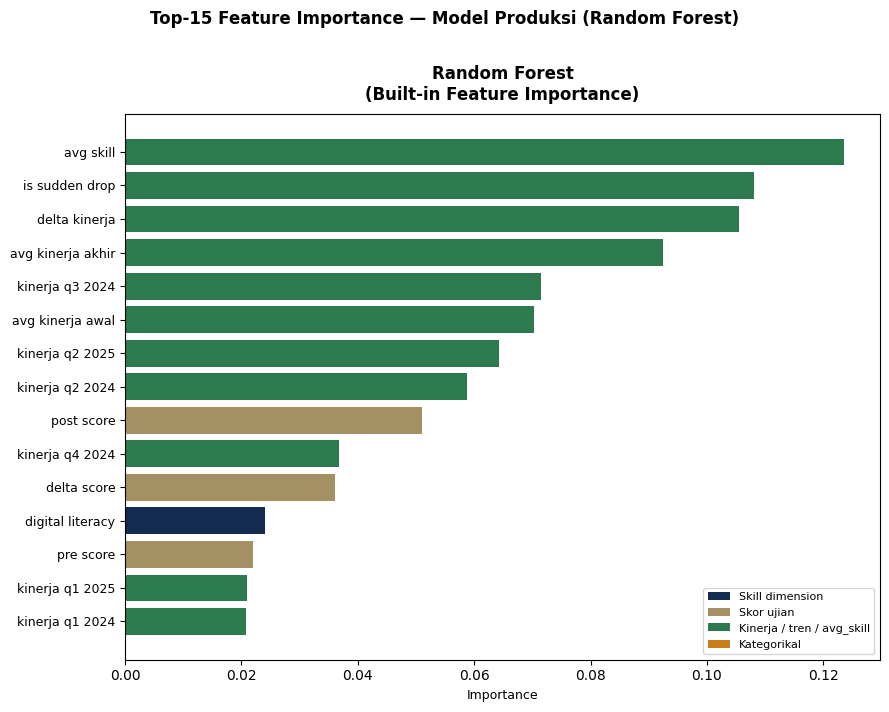

In [ ]:
from sklearn.inspection import permutation_importance

top_n      = 15
best_model = results[best_name_safe]["model"]

# Cek apakah pipeline punya built-in importance (tree-based)
clf_step     = best_model.named_steps["clf"]
has_builtin  = hasattr(clf_step, "feature_importances_")

if has_builtin:
    imp_vals   = clf_step.feature_importances_
    imp_source = "Built-in Feature Importance"
else:
    perm = permutation_importance(
        best_model, X_test_proc, y_test,
        n_repeats=30, random_state=SEED, scoring="f1_macro"
    )
    imp_vals   = perm.importances_mean
    imp_source = "Permutation Importance (test set)"

min_len    = min(len(imp_vals), len(all_feature_names))
feat_names = all_feature_names[:min_len]
imp_vals   = imp_vals[:min_len]

idx_sorted = np.argsort(imp_vals)[::-1][:top_n]
top_names  = [feat_names[i].replace("skill_","").replace("_"," ")
                            .replace("divisi_","div:")
                            .replace("status_sertifikat_","sert:")
              for i in idx_sorted]
top_vals   = imp_vals[idx_sorted]

def feat_color(name):
    if "skill_" in name:                             return "#132B50"
    if name in ["pre_score","post_score","delta_score"]: return "#A49063"
    if any(k in name for k in ["kinerja","avg_skill","delta_kinerja",
                                "is_sudden_drop"]): return "#2d7a4f"
    return "#c97c1a"

bar_c = [feat_color(feat_names[i]) for i in idx_sorted]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(len(top_vals)), top_vals[::-1], color=bar_c[::-1], edgecolor="none")
ax.set_yticks(range(len(top_vals)))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_title(f"{best_name_safe}\n({imp_source})", fontweight="bold", pad=10)
ax.set_xlabel("Importance", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#132B50", label="Skill dimension"),
    Patch(facecolor="#A49063", label="Skor ujian"),
    Patch(facecolor="#2d7a4f", label="Kinerja / tren / avg_skill"),
    Patch(facecolor="#c97c1a", label="Kategorikal"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="lower right")

plt.suptitle(f"Top-{top_n} Feature Importance — Model Produksi ({best_name_safe})",
             fontweight="bold", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("tindakan_plot_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# ── Tabel importance
importance_df = pd.DataFrame({
    "Feature":    [feat_names[i] for i in idx_sorted],
    "Importance": top_vals,
    "Source":     imp_source,
}).set_index("Feature")

importance_df.index = [i.replace("skill_","skill:").replace("_"," ")
                        for i in importance_df.index]

print(f"=== Top {top_n} Fitur — {best_name_safe} ({imp_source}) ===")
print(importance_df["Importance"].round(4).to_string())


=== Top 15 Fitur — Random Forest (Built-in Feature Importance) ===
avg skill                 0.1236
is sudden drop            0.1080
delta kinerja             0.1056
avg kinerja akhir         0.0924
kinerja q3 2024           0.0714
avg kinerja awal          0.0703
kinerja q2 2025           0.0642
kinerja q2 2024           0.0588
post score                0.0511
kinerja q4 2024           0.0367
delta score               0.0360
skill:digital literacy    0.0240
pre score                 0.0220
kinerja q1 2025           0.0209
kinerja q1 2024           0.0209


---
## 6. Hyperparameter Tuning — Model Terbaik

GridSearchCV dijalankan untuk model yang dipilih secara dinamis (`best_name_safe`).
Parameter grid didefinisikan untuk semua model yang mungkin terpilih.


In [ ]:
# ── GridSearch pada model terbaik valid (best_name_safe dari Section 4)
print(f"Menjalankan GridSearchCV untuk: {best_name_safe}")

param_grids = {
    "Random Forest": {
        "clf__n_estimators":    [100, 200, 300],
        "clf__max_depth":       [None, 10, 20],
        "clf__min_samples_leaf":[1, 2, 5],
        "clf__max_features":    ["sqrt", "log2"],
    },
    "Gradient Boosting": {
        "clf__n_estimators":  [100, 200],
        "clf__learning_rate": [0.05, 0.1, 0.2],
        "clf__max_depth":     [3, 5, 7],
    },
    "Decision Tree": {
        "clf__max_depth":        [5, 10, 15, None],
        "clf__min_samples_leaf": [1, 3, 5],
        "clf__criterion":        ["gini", "entropy"],
    },
    "Extra Trees": {
        "clf__n_estimators":    [100, 200, 300],
        "clf__min_samples_leaf":[1, 2, 5],
        "clf__max_features":    ["sqrt", "log2"],
    },
    "SVM (RBF)": {
        "clf__C":     [0.1, 1.0, 10.0],
        "clf__gamma": ["scale", "auto"],
    },
    "Logistic Regression": {
        "clf__C":        [0.01, 0.1, 1.0, 10.0],
        "clf__solver":   ["lbfgs", "saga"],
        "clf__max_iter": [500, 1000],
    },
}

base_model_map = {
    "Random Forest":      RandomForestClassifier(random_state=SEED, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingClassifier(random_state=SEED),
    "Decision Tree":      DecisionTreeClassifier(random_state=SEED),
    "Extra Trees":        ExtraTreesClassifier(random_state=SEED, n_jobs=-1),
    "SVM (RBF)":          SVC(kernel="rbf", probability=True, random_state=SEED),
    "Logistic Regression":LogisticRegression(random_state=SEED),
}

if best_name_safe in param_grids:
    pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=SEED, k_neighbors=2)),
        ("clf",   base_model_map[best_name_safe])
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grids[best_name_safe],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="f1_macro",
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train_proc, y_train)

    best_tuned_model  = grid_search.best_estimator_
    y_pred_best_tuned = best_tuned_model.predict(X_test_proc)
    tuned_f1          = f1_score(y_test, y_pred_best_tuned, average="macro")
    tuned_acc         = accuracy_score(y_test, y_pred_best_tuned)

    print(f"Best params : {grid_search.best_params_}")
    print(f"Best CV F1  : {grid_search.best_score_:.4f}")
    print(f"Test Accuracy (tuned {best_name_safe}) : {tuned_acc:.4f}")
    print(f"Test F1-macro (tuned {best_name_safe}) : {tuned_f1:.4f}")

else:
    # Model tanpa param_grid tetap pakai versi tanpa tuning
    best_tuned_model  = results[best_name_safe]["model"]
    y_pred_best_tuned = results[best_name_safe]["y_pred"]
    tuned_f1          = results[best_name_safe]["test_f1"]
    tuned_acc         = results[best_name_safe]["test_acc"]
    print(f"{best_name_safe} tidak memiliki param_grid — menggunakan model default.")
    print(f"Test Accuracy : {tuned_acc:.4f}")
    print(f"Test F1-macro : {tuned_f1:.4f}")


Menjalankan GridSearchCV untuk: Random Forest
Best params : {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Best CV F1  : 0.9269
Test Accuracy (tuned Random Forest) : 0.9375
Test F1-macro (tuned Random Forest) : 0.9213


In [ ]:
# ── Simpan best model ke file
import pickle, os

artifacts = {
    "model":             best_tuned_model,
    "model_name":        best_name_safe,
    "preprocessor":      preprocessor,
    "label_tindakan":    LABEL_TINDAKAN,
    "label_tindakan_list": LABEL_TINDAKAN_LIST,
    "feature_names":     ALL_FEATURES,
    "skill_cols":        skill_cols,
    "kinerja_cols":      kinerja_cols,
}
with open("sdc_model_tindakan.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print(f"Model tersimpan: {best_name_safe} (post-tuning)")
print(f"File : sdc_model_tindakan.pkl")
print(f"Ukuran: {os.path.getsize('sdc_model_tindakan.pkl') / 1024:.1f} KB")


Model tersimpan: Random Forest (post-tuning)
File : sdc_model_tindakan.pkl
Ukuran: 2074.5 KB


---
## 7. Inference — Simulasi Rekomendasi Tindakan untuk Manajer


In [ ]:
# ── Panduan tindakan per label
PANDUAN_TINDAKAN = {
    0: {
        "label":     "Coaching Intensif",
        "prioritas": "Tinggi",
        "langkah": [
            "Jadwalkan sesi 1-on-1 minimal 2x per bulan",
            "Pasangkan dengan mentor senior dari divisi yang sama",
            "Buat Individual Development Plan (IDP) 30/60/90 hari",
            "Monitor KPI mingguan dan berikan feedback langsung",
            "Pertimbangkan rotasi tugas untuk stimulasi baru",
        ],
        "target": "Peningkatan avg_skill minimal 0.3 poin dalam 3 bulan",
    },
    1: {
        "label":     "Pengawasan & Evaluasi Ketat",
        "prioritas": "Menengah-Tinggi",
        "langkah": [
            "Lakukan review kinerja formal setiap bulan",
            "Perbarui atau perpanjang sertifikasi yang kadaluarsa",
            "Identifikasi faktor eksternal penyebab penurunan kinerja",
            "Beri peringatan lisan jika tidak ada perbaikan dalam 60 hari",
            "Dokumentasikan semua interaksi untuk record HR",
        ],
        "target": "Stabilisasi kinerja kembali ke baseline dalam 2 bulan",
    },
    2: {
        "label":     "Pertahankan & Stabilkan",
        "prioritas": "Rutin",
        "langkah": [
            "Lanjutkan review kinerja kuartalan reguler",
            "Pastikan beban kerja tidak berlebihan",
            "Libatkan dalam program mentoring sebagai observer",
            "Berikan apresiasi atas konsistensi kinerja",
            "Pantau potensi naik ke label Percepatan Karir",
        ],
        "target": "Pertahankan kinerja stabil, identifikasi potensi pengembangan",
    },
    3: {
        "label":     "Percepatan Karir",
        "prioritas": "Strategis",
        "langkah": [
            "Ajukan ke program fast-track atau talent pool perusahaan",
            "Berikan tanggung jawab tambahan atau kepemimpinan tim kecil",
            "Diskusikan jalur promosi dalam 6–12 bulan ke depan",
            "Daftarkan ke sertifikasi level lanjutan (ASEAN/internasional)",
            "Jadikan sebagai kandidat mentor untuk pegawai baru",
        ],
        "target": "Promosi atau peningkatan jabatan dalam 12 bulan",
    },
    4: {
        "label":     "Retensi & Risiko Resign",
        "prioritas": "Kritis",
        "langkah": [
            "Segera lakukan exit risk interview secara informal dan rahasia",
            "Identifikasi faktor ketidakpuasan (kompensasi, lingkungan, beban kerja)",
            "Tawarkan solusi konkret: penyesuaian shift, proyek baru, atau kompensasi",
            "Libatkan HR untuk program retensi khusus",
            "Lakukan check-in mingguan selama 4 minggu pertama",
        ],
        "target": "Stabilisasi engagement dalam 30 hari, hindari turnover",
    },
}
print("Panduan tindakan terdefinisi untuk 5 label.")


Panduan tindakan terdefinisi untuk 5 label.


In [ ]:
# ── Fungsi inference
def predict_tindakan_manajer(
    skill_dict: dict,
    pre_score: int,
    post_score: int,
    kinerja_list: list,
    divisi: str,
    status_sertifikat: str,
    model_artifacts: dict,
) -> dict:
    """
    Prediksi label tindakan manajer untuk satu pegawai.

    Parameters
    ----------
    skill_dict       : dict  — key = nama skill (tanpa 'skill_'), value = float 1.0–5.0
    pre_score        : int
    post_score       : int
    kinerja_list     : list of 6 float  [Q1_24, Q2_24, Q3_24, Q4_24, Q1_25, Q2_25]
    divisi           : str
    status_sertifikat: str
    model_artifacts  : dict  (dari sdc_model_tindakan.pkl)

    Returns
    -------
    dict dengan keys: label_id, label_name, prioritas, confidence,
                      semua_proba, langkah_tindakan, target
    """
    model         = model_artifacts["model"]
    prep          = model_artifacts["preprocessor"]
    skill_cols_   = model_artifacts["skill_cols"]
    kinerja_cols_ = model_artifacts["kinerja_cols"]
    feat_names_   = model_artifacts["feature_names"]

    row = {}
    for sc in skill_cols_:
        row[sc] = skill_dict.get(sc.replace("skill_", ""), 3.0)
    for i, kc in enumerate(kinerja_cols_):
        row[kc] = kinerja_list[i]

    row["pre_score"]   = pre_score
    row["post_score"]  = post_score
    row["delta_score"] = post_score - pre_score

    avg_skill = float(np.mean([row[sc] for sc in skill_cols_]))
    row["avg_skill"] = round(avg_skill, 3)

    q = kinerja_list
    avg_awal  = round(sum(q[:3]) / 3, 3)
    avg_akhir = round(sum(q[3:]) / 3, 3)
    delta_kin = round(avg_akhir - avg_awal, 3)
    row["avg_kinerja_awal"]  = avg_awal
    row["avg_kinerja_akhir"] = avg_akhir
    row["delta_kinerja"]     = delta_kin
    row["is_sudden_drop"]    = int(avg_awal >= 3.0 and delta_kin <= -0.20)

    row["divisi"]            = divisi
    row["status_sertifikat"] = status_sertifikat

    X_input = pd.DataFrame([row])[feat_names_]
    X_proc  = prep.transform(X_input)

    label_id = int(
        model.predict(X_proc)[0]
    )

    proba = model.predict_proba(
        X_proc
    )[0]

    class_idx = list(
        model.classes_
    ).index(label_id)

    confidence = float(
        proba[class_idx]
    )
    panduan    = PANDUAN_TINDAKAN[label_id]

    return {
        "label_id":         label_id,
        "label_name":       panduan["label"],
        "prioritas":        panduan["prioritas"],
        "confidence":       round(confidence * 100, 2),
        "semua_proba":      {PANDUAN_TINDAKAN[i]["label"]: round(float(p)*100, 2)
                             for i, p in enumerate(proba)},
        "langkah_tindakan": panduan["langkah"],
        "target":           panduan["target"],
        "avg_skill":        round(avg_skill, 3),
        "delta_kinerja":    delta_kin,
        "is_sudden_drop":   bool(row["is_sudden_drop"]),
    }


def tampilkan_hasil(hasil: dict, nama: str = ""):
    print(f"{'='*60}")
    if nama:
        print(f"  Pegawai   : {nama}")
    print(f"  Label     : {hasil['label_name']}")
    print(f"  Prioritas : {hasil['prioritas']}")
    print(f"  Confidence: {hasil['confidence']}%")
    print(f"  Avg Skill : {hasil['avg_skill']:.2f}  |  "
          f"Delta Kinerja: {hasil['delta_kinerja']:+.3f}  |  "
          f"Sudden Drop: {'Ya \u26a0' if hasil['is_sudden_drop'] else 'Tidak'}")
    print()
    print("  Probabilitas per label:")
    for lbl, prob in hasil["semua_proba"].items():
        bar = "\u2588" * int(prob / 5)
        print(f"    {lbl:<35} {prob:5.1f}%  {bar}")
    print()
    print("  Langkah Tindakan:")
    for i, langkah in enumerate(hasil["langkah_tindakan"], 1):
        print(f"    {i}. {langkah}")
    print(f"\n  Target: {hasil['target']}")
    print(f"{'='*60}")

print("Fungsi predict_tindakan_manajer() dan tampilkan_hasil() siap.")


Fungsi predict_tindakan_manajer() dan tampilkan_hasil() siap.


In [ ]:
import pickle
with open("sdc_model_tindakan.pkl", "rb") as f:
    artifacts_t = pickle.load(f)

# ── Contoh 1: Skill & kinerja rendah → ekspektasi Coaching Intensif
contoh_1 = predict_tindakan_manajer(
    skill_dict={
        "komunikasi": 2.3, "layanan_tamu": 2.5, "penguasaan_teknis": 2.1,
        "kepatuhan_sop": 2.4, "kepemimpinan": 1.8, "bahasa_asing": 1.9,
        "problem_solving": 2.2, "digital_literacy": 2.0,
    },
    pre_score=32, post_score=44,
    kinerja_list=[2.3, 2.1, 2.4, 2.2, 2.0, 2.1],
    divisi="Food & Beverage",
    status_sertifikat="Belum",
    model_artifacts=artifacts_t,
)
tampilkan_hasil(contoh_1, "Contoh 1 — Commis Chef (skill & kinerja rendah)")


  Pegawai   : Contoh 1 — Commis Chef (skill & kinerja rendah)
  Label     : Coaching Intensif
  Prioritas : Tinggi
  Confidence: 99.5%
  Avg Skill : 2.15  |  Delta Kinerja: -0.167  |  Sudden Drop: Tidak

  Probabilitas per label:
    Coaching Intensif                    99.5%  ███████████████████
    Pengawasan & Evaluasi Ketat           0.0%  
    Pertahankan & Stabilkan               0.5%  
    Percepatan Karir                      0.0%  
    Retensi & Risiko Resign               0.0%  

  Langkah Tindakan:
    1. Jadwalkan sesi 1-on-1 minimal 2x per bulan
    2. Pasangkan dengan mentor senior dari divisi yang sama
    3. Buat Individual Development Plan (IDP) 30/60/90 hari
    4. Monitor KPI mingguan dan berikan feedback langsung
    5. Pertimbangkan rotasi tugas untuk stimulasi baru

  Target: Peningkatan avg_skill minimal 0.3 poin dalam 3 bulan


In [ ]:
# ── Contoh 2: Kinerja tiba-tiba drop dari baseline bagus → ekspektasi Retensi
contoh_2 = predict_tindakan_manajer(
    skill_dict={
        "komunikasi": 3.9, "layanan_tamu": 4.1, "penguasaan_teknis": 3.7,
        "kepatuhan_sop": 4.0, "kepemimpinan": 3.5, "bahasa_asing": 3.6,
        "problem_solving": 3.8, "digital_literacy": 3.4,
    },
    pre_score=68, post_score=87,
    kinerja_list=[3.8, 3.9, 4.0, 3.2, 2.9, 2.8],
    divisi="Akomodasi",
    status_sertifikat="Aktif",
    model_artifacts=artifacts_t,
)
tampilkan_hasil(contoh_2, "Contoh 2 — Front Desk Officer (sudden drop)")


  Pegawai   : Contoh 2 — Front Desk Officer (sudden drop)
  Label     : Retensi & Risiko Resign
  Prioritas : Kritis
  Confidence: 76.5%
  Avg Skill : 3.75  |  Delta Kinerja: -0.933  |  Sudden Drop: Ya ⚠

  Probabilitas per label:
    Coaching Intensif                     0.0%  
    Pengawasan & Evaluasi Ketat           5.0%  █
    Pertahankan & Stabilkan              16.5%  ███
    Percepatan Karir                      2.0%  
    Retensi & Risiko Resign              76.5%  ███████████████

  Langkah Tindakan:
    1. Segera lakukan exit risk interview secara informal dan rahasia
    2. Identifikasi faktor ketidakpuasan (kompensasi, lingkungan, beban kerja)
    3. Tawarkan solusi konkret: penyesuaian shift, proyek baru, atau kompensasi
    4. Libatkan HR untuk program retensi khusus
    5. Lakukan check-in mingguan selama 4 minggu pertama

  Target: Stabilisasi engagement dalam 30 hari, hindari turnover


In [ ]:
# ── Contoh 3: Skill tinggi + kinerja naik konsisten → ekspektasi Percepatan Karir
contoh_3 = predict_tindakan_manajer(
    skill_dict={
        "komunikasi": 4.3, "layanan_tamu": 4.4, "penguasaan_teknis": 4.0,
        "kepatuhan_sop": 4.2, "kepemimpinan": 4.1, "bahasa_asing": 3.8,
        "problem_solving": 4.2, "digital_literacy": 3.9,
    },
    pre_score=72, post_score=96,
    kinerja_list=[3.4, 3.6, 3.8, 4.0, 4.2, 4.4],
    divisi="Tur & Perjalanan",
    status_sertifikat="Aktif",
    model_artifacts=artifacts_t,
)
tampilkan_hasil(contoh_3, "Contoh 3 — Tour Leader (kandidat percepatan karir)")


  Pegawai   : Contoh 3 — Tour Leader (kandidat percepatan karir)
  Label     : Pertahankan & Stabilkan
  Prioritas : Rutin
  Confidence: 60.5%
  Avg Skill : 4.11  |  Delta Kinerja: +0.600  |  Sudden Drop: Tidak

  Probabilitas per label:
    Coaching Intensif                     0.0%  
    Pengawasan & Evaluasi Ketat           0.5%  
    Pertahankan & Stabilkan              60.5%  ████████████
    Percepatan Karir                     37.0%  ███████
    Retensi & Risiko Resign               2.0%  

  Langkah Tindakan:
    1. Lanjutkan review kinerja kuartalan reguler
    2. Pastikan beban kerja tidak berlebihan
    3. Libatkan dalam program mentoring sebagai observer
    4. Berikan apresiasi atas konsistensi kinerja
    5. Pantau potensi naik ke label Percepatan Karir

  Target: Pertahankan kinerja stabil, identifikasi potensi pengembangan


In [ ]:
# ── Contoh 4: Profil normal, kinerja stabil → ekspektasi Pertahankan
contoh_4 = predict_tindakan_manajer(
    skill_dict={
        "komunikasi": 3.3, "layanan_tamu": 3.5, "penguasaan_teknis": 3.4,
        "kepatuhan_sop": 3.6, "kepemimpinan": 2.8, "bahasa_asing": 3.0,
        "problem_solving": 3.2, "digital_literacy": 3.1,
    },
    pre_score=55, post_score=72,
    kinerja_list=[3.1, 3.0, 3.2, 3.1, 3.2, 3.1],
    divisi="Food & Beverage",
    status_sertifikat="Aktif",
    model_artifacts=artifacts_t,
)
tampilkan_hasil(contoh_4, "Contoh 4 — F&B Attendant (profil stabil)")


  Pegawai   : Contoh 4 — F&B Attendant (profil stabil)
  Label     : Pertahankan & Stabilkan
  Prioritas : Rutin
  Confidence: 88.35%
  Avg Skill : 3.24  |  Delta Kinerja: +0.033  |  Sudden Drop: Tidak

  Probabilitas per label:
    Coaching Intensif                     0.0%  
    Pengawasan & Evaluasi Ketat           9.4%  █
    Pertahankan & Stabilkan              88.3%  █████████████████
    Percepatan Karir                      2.2%  
    Retensi & Risiko Resign               0.0%  

  Langkah Tindakan:
    1. Lanjutkan review kinerja kuartalan reguler
    2. Pastikan beban kerja tidak berlebihan
    3. Libatkan dalam program mentoring sebagai observer
    4. Berikan apresiasi atas konsistensi kinerja
    5. Pantau potensi naik ke label Percepatan Karir

  Target: Pertahankan kinerja stabil, identifikasi potensi pengembangan


In [ ]:
# ── Contoh 5: Kinerja turun bertahap + sertifikat kadaluarsa → ekspektasi Pengawasan
contoh_5 = predict_tindakan_manajer(
    skill_dict={
        "komunikasi": 3.0, "layanan_tamu": 3.2, "penguasaan_teknis": 3.1,
        "kepatuhan_sop": 2.9, "kepemimpinan": 2.4, "bahasa_asing": 2.5,
        "problem_solving": 2.8, "digital_literacy": 2.7,
    },
    pre_score=48, post_score=58,
    kinerja_list=[3.1, 2.9, 2.8, 2.6, 2.5, 2.4],
    divisi="Akomodasi",
    status_sertifikat="Kadaluarsa",
    model_artifacts=artifacts_t,
)
tampilkan_hasil(contoh_5, "Contoh 5 — Housekeeping Attendant (kinerja turun + sertif kadaluarsa)")


  Pegawai   : Contoh 5 — Housekeeping Attendant (kinerja turun + sertif kadaluarsa)
  Label     : Coaching Intensif
  Prioritas : Tinggi
  Confidence: 49.02%
  Avg Skill : 2.83  |  Delta Kinerja: -0.433  |  Sudden Drop: Tidak

  Probabilitas per label:
    Coaching Intensif                    49.0%  █████████
    Pengawasan & Evaluasi Ketat          44.9%  ████████
    Pertahankan & Stabilkan               5.1%  █
    Percepatan Karir                      0.5%  
    Retensi & Risiko Resign               0.5%  

  Langkah Tindakan:
    1. Jadwalkan sesi 1-on-1 minimal 2x per bulan
    2. Pasangkan dengan mentor senior dari divisi yang sama
    3. Buat Individual Development Plan (IDP) 30/60/90 hari
    4. Monitor KPI mingguan dan berikan feedback langsung
    5. Pertimbangkan rotasi tugas untuk stimulasi baru

  Target: Peningkatan avg_skill minimal 0.3 poin dalam 3 bulan


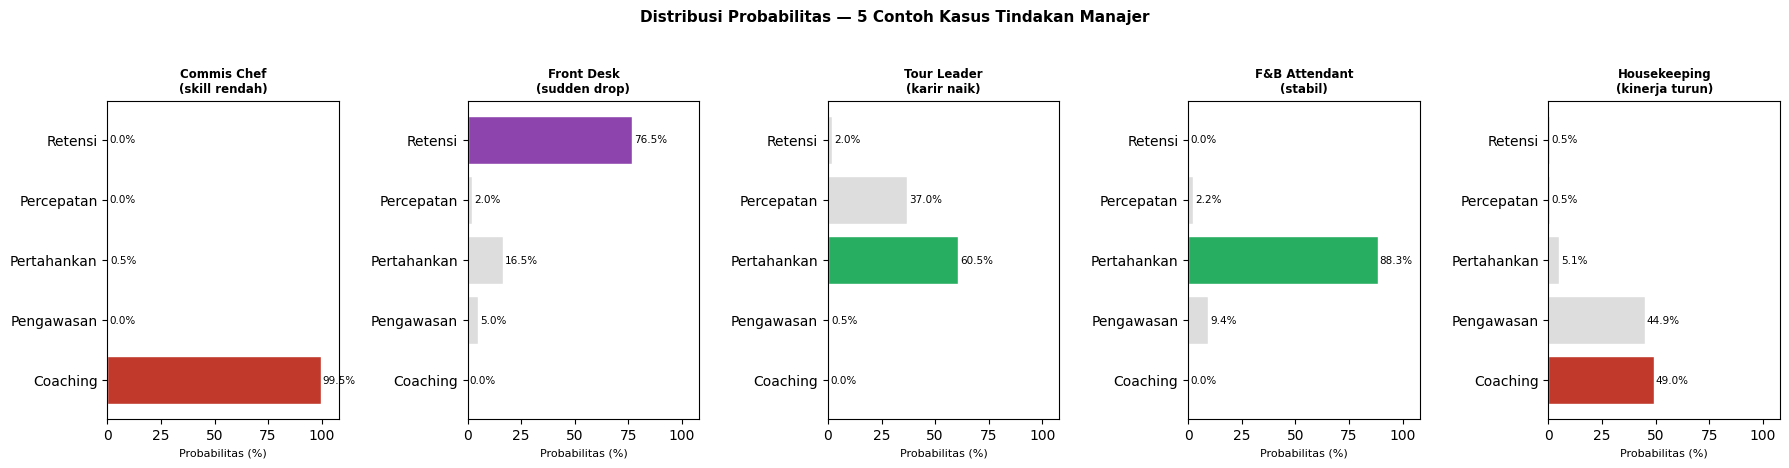

In [ ]:
# ── Visualisasi probabilitas 5 contoh kasus
roc_colors_5 = ["#c0392b", "#e67e22", "#27ae60", "#2980b9", "#8e44ad"]
kasus_list   = [contoh_1, contoh_2, contoh_3, contoh_4, contoh_5]
kasus_names  = [
    "Commis Chef\n(skill rendah)",
    "Front Desk\n(sudden drop)",
    "Tour Leader\n(karir naik)",
    "F&B Attendant\n(stabil)",
    "Housekeeping\n(kinerja turun)",
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5))
for ax, kasus, k_name in zip(axes, kasus_list, kasus_names):
    probas = list(kasus["semua_proba"].values())
    bar_c  = [roc_colors_5[i] if i == kasus["label_id"] else "#ddd"
              for i in range(5)]
    ax.barh(LABEL_SHORT, probas, color=bar_c, edgecolor="white")
    ax.set_xlim(0, 108)
    ax.set_xlabel("Probabilitas (%)", fontsize=8)
    ax.set_title(k_name, fontweight="bold", fontsize=8.5)
    for j, val in enumerate(probas):
        ax.text(val + 1, j, f"{val:.1f}%", va="center", fontsize=7.5)

plt.suptitle("Distribusi Probabilitas — 5 Contoh Kasus Tindakan Manajer",
             fontweight="bold", y=1.03, fontsize=11)
plt.tight_layout()
plt.savefig("tindakan_plot_inference_examples.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 8. Ringkasan & Rekomendasi untuk Implementasi Flask

### Hasil Evaluasi Model


In [ ]:
# ── Tabel ringkasan final
print("=" * 70)
print("RINGKASAN PERFORMA MODEL — SDC Manager Action Recommendation")
print("=" * 70)
print(df_results.to_string(index=True))
print()
print(f"Model terpilih untuk produksi: {best_name_safe} (post-tuning)")
print(f"  Test Accuracy : {tuned_acc:.4f}")
print(f"  Test F1-macro : {tuned_f1:.4f}")
print()

# Narasi otomatis — tidak hardcode nama model
excluded = df_results[df_results["Suspect Overfit"] == "YA"]["Model"].tolist()
if excluded:
    print(f"Catatan pemilihan model:")
    print(f"  - Dikecualikan karena suspect overfit (F1>=1.0 atau gap >15%): {', '.join(excluded)}")
    print(f"  - {best_name_safe} dipilih sebagai model valid terbaik.")
    if tuned_f1 >= 0.999:
        print(f"  Perhatian: model terpilih juga menghasilkan F1={tuned_f1:.4f} setelah tuning.")
        print(f"    Ini mengindikasikan data dummy terlalu deterministik.")
        print(f"    Perlu validasi ulang dengan data nyata sebelum deploy produksi.")


RINGKASAN PERFORMA MODEL — SDC Manager Action Recommendation
                 Model  CV F1-macro (mean)  CV F1-macro (std)  Test Accuracy  Test F1-macro  CV-Test Gap Suspect Overfit
1        Random Forest            0.922070           0.036620         0.9500       0.929778      -0.0077              OK
2    Gradient Boosting            0.901436           0.091885         0.9625       0.920566      -0.0191              OK
3          Extra Trees            0.832495           0.063425         0.8750       0.873915      -0.0414              OK
4            SVM (RBF)            0.843760           0.048154         0.8375       0.860099      -0.0163              OK
5                  KNN            0.723997           0.032336         0.7375       0.764747      -0.0407              OK
6        Decision Tree            0.794801           0.135156         0.8875       0.752676       0.0421              OK
7  Logistic Regression            0.794388           0.043264         0.7875       0.750251 

---
### Cara Integrasi ke Flask

```python
# app.py (snippet)
import pickle, pandas as pd
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load model saat startup
with open("sdc_model_tindakan.pkl", "rb") as f:
    artifacts = pickle.load(f)

@app.route("/api/tindakan-manajer", methods=["POST"])
def tindakan_manajer():
    data   = request.json
    result = predict_tindakan_manajer(
        skill_dict        = data["skills"],
        pre_score         = data["pre_score"],
        post_score        = data["post_score"],
        kinerja_list      = data["kinerja"],
        divisi            = data["divisi"],
        status_sertifikat = data["status_sertifikat"],
        model_artifacts   = artifacts,
    )
    return jsonify(result)
```

### File yang dihasilkan notebook ini

| File | Keterangan |
|------|-----------|
| `sdc_model_tindakan.pkl` | Model + preprocessor + metadata (siap deploy) |
| `tindakan_plot_*.png` | Semua visualisasi (8 file) |

### Catatan untuk pengembangan selanjutnya
1. **Label Retensi** — jumlah sampel sangat sedikit (10); performa akan meningkat signifikan dengan data nyata
2. **Threshold tuning** — untuk label kritis (Coaching, Retensi), pertimbangkan menurunkan threshold agar recall lebih tinggi
3. **Data nyata** — ganti data dummy dengan data riil dari sistem SDC
4. **Retraining pipeline** — tambahkan versioning model saat data bertambah
